In [1]:
# auto-reload changed source files when they are imported
%reload_ext autoreload
%autoreload 2

# add top repo dir to path so that src can be imported
# import sys
#
# # from processing.schnet import model_save_path
#
# sys.path.append("..")
#
# # %matplotlib inline

from tqdm import tqdm
import time
import os
from datetime import datetime
import copy
from pathlib import Path
import json

os.environ["TORCH_HOME"] = r"D:\cache\torch_cache"
os.environ["TMP"] = r"D:\cache\tmp"
os.environ["TEMP"] = r"D:\cache\tmp"

import torch
import numpy as np
from torch_geometric.loader import DataLoader
from src.data.dataset import Crystals
from src.utils.loss import MSELoss, L1Loss, RMSELoss, MSLELoss, CosSimLoss, IoULoss, KLDivLoss, CombLoss, AdaptiveCombLoss
from src.utils.util import drop
import matplotlib.pyplot as plt
from models import model_wavenumbers,PaiNN_raman0, PaiNN_raman2, PaiNN_raman3

/home/elemantro/PythonProjects/graph12/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: No module named 'src'

node_attributes = [atomic_number,atomic_weight,electronegativity,vdw,pold,at_radius,occ,Biso]

iou = 0.5

kl = 0.006

cossim = 0.18

rmse = 0.18, variance

mse = 0.028

mae = 0.1

msle = 0.029, variance

In [ ]:
device = torch.device('cuda')
model = PaiNN_raman0().to(device)
# loss_fn = MSELoss()
loss_fn = CombLoss(
    (1, MSELoss()),
    # (1, L1Loss()),
    # (1,MSLELoss()),
    # (0.2,RMSELoss()),
    (1, CosSimLoss())
    # (1, KLDivLoss()),
    # (1,IoULoss())
    )
# loss_fn = AdaptiveCombLoss(
#     (1, MSELoss()),
#     (1, L1Loss()),
#     # (1,MSLELoss()),
#     (0.4,RMSELoss()),
#     # (1, CosSimLoss()),
#     # (1, KLDivLoss()),
#     (1, IoULoss())
#     )
loss_name = str(loss_fn)
model_name = str(model)
now = datetime.now()
dt_string = now.strftime("%Y%m%d-%H%M%S")
dataset_path = '../data/processed/v6.pt'
dataset = Crystals(dataset_path)
save_model_dir = Path(f'models/{model_name}_{loss_name}')
save_model_dir.mkdir(parents=True,exist_ok=True)

train_dataset, val_dataset, test_dataset = dataset.get_splits(deterministic=True)
train_loader = DataLoader(train_dataset, batch_size=64)
val_loader = DataLoader(val_dataset, batch_size=64)

fn = KLDivLoss()
def val(model, val_dataloader):
    model.eval()
    with torch.inference_mode():
        mse = 0
        for data in val_dataloader:
            data = data.to(device)
            pred = model(data)

            mse += fn(pred, data.y)
        return mse / len(val_dataloader)

train_loss = []
val_loss = []
display_epochs = 10
best_model_wts = copy.deepcopy(model.state_dict())
best_val_loss = 0.007
model_save_path = None

In [7]:
def train(model,start,end,lr):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    global model_save_path, best_model_wts, best_val_loss
    try:
        for epoch in tqdm(range(start,end+1)):
            model.train()
            optimizer.zero_grad()
            for data in train_loader:
                data = data.to(device)
                pred = model(data)
                loss = loss_fn(pred, data.y)
                loss.backward()
                optimizer.step()

            train_kl = val(model, train_loader)
            val_kl = val(model, val_loader)
            train_loss.append(train_kl.item())
            val_loss.append(val_kl.item())

            if epoch % display_epochs == 0:
                tqdm.write(f"validation {loss_name} loss: {val_kl.item()}")
                tqdm.write(f"train {loss_name} loss: {train_kl.item()}")
            if val_kl < best_val_loss:
                best_val_loss = val_kl
                best_model_wts = copy.deepcopy(model.state_dict())
                model_save_path = save_model_dir / f'{dt_string}_epoch{epoch:05d}_kl{val_kl:.4f}.pt'
                torch.save(model.state_dict(),model_save_path)
                tqdm.write(f"validation {loss_name} loss: {val_kl.item()}")
                tqdm.write(f"model saved to {model_save_path}")
            time.sleep(3)
    except KeyboardInterrupt as e:
        Exception(e)
        tqdm.write(f"validation {loss_name} loss: {val_kl.item()}")
        tqdm.write(f"train {loss_name} loss: {train_kl.item()}")
        return epoch,val_kl,model_save_path,best_model_wts
    return epoch,val_kl,model_save_path,best_model_wts

In [8]:
epoch,val_kl,model_save_path,best_model_wts = train(model,0,1000,lr=1e-5)

  0%|          | 0/21 [00:21<?, ?it/s]


UnboundLocalError: cannot access local variable 'val_kl' where it is not associated with a value

In [ ]:
epoch,val_kl,model_save_path,best_model_wts = train(model,180,1000,lr=1e-5)

In [ ]:
epoch,val_kl,model_save_path,best_model_wts = train(model,950,1200,lr=5e-6)

In [ ]:
from src.utils.metrics import kldiv
best_model = PaiNN_raman3().to(device)
best_model.load_state_dict(best_model_wts)
print(kldiv(model,device,val_dataset,514)[0])
print(kldiv(best_model,device,val_dataset,514)[0])

In [ ]:
from src.visualization.plotting import plot_spectra, save_all
from src.utils.metrics import kldiv
from matplotlib.ticker import MultipleLocator
import seaborn as sns

sns.set_style("whitegrid")
predict_dir_val = Path(f"predict/{model_name}_{loss_name}/val")
predict_dir_val.mkdir(parents=True,exist_ok=True)
predict_dir_test = Path(f"predict/{model_name}_{loss_name}/test")
predict_dir_test.mkdir(parents=True,exist_ok=True)
predict_dirs_test = {}
predict_dirs_val = {}
loss_dir = Path(f"loss/{model_name}_{loss_name}")
loss_dir.mkdir(parents=True,exist_ok=True)
model_save_path = save_model_dir / f'{dt_string}_epoch{epoch}_{loss_name}{val_kl:.4f}.pt'
torch.save(model.state_dict(),model_save_path)
for i in dataset.wl_list:
    path = Path(str(i))
    predict_dirs_val[i] = predict_dir_val/path
    predict_dirs_test[i] = predict_dir_test/path
    predict_dirs_val[i].mkdir(parents=True,exist_ok=True)
    predict_dirs_test[i].mkdir(parents=True,exist_ok=True)

try:

    best_model = PaiNN_raman3().to(device)
    best_model.load_state_dict(best_model_wts)

    param_model = model

    print(kldiv(param_model,device,val_dataset,514)[0])
    train_loss_path = loss_dir/"train.json"
    val_loss_path = loss_dir/"val.json"
    train_loss_path.write_text(json.dumps(train_loss,indent=2))
    val_loss_path.write_text(json.dumps(val_loss,indent=2))


    plt.plot(train_loss,linewidth=.2,label="train loss")
    plt.plot(val_loss,linewidth=.2, label="validation loss")
    # plt.ylim(0.005,0.02)
    # ax = plt.gca()
    # # ax.yaxis.set_major_locator(MultipleLocator(5e-2))
    plt.title("learning curves")
    plt.ylabel('kl-div')
    plt.xlabel('epoch')
    plt.legend()
    plt.savefig(f"{loss_dir}/loss.png")
    plt.show()
    save_all(param_model,device,val_dataset,predict_dirs_val)
except KeyboardInterrupt:
    print("interrupted")

In [ ]:
from models import Ensemble2
from src.utils.metrics import kldiv
device = "cuda"
# model_path1 = "models/painn_1mse_1mae_1msle_1rmse_1cossim_1kl_/20251003-175924_epoch1000_kl-div0.5043.pt"
# model_path2 = "models/painn2_1mse_1cossim_1kl/20251014-155744_epoch00795_kl0.0083.pt"
# model_path3 = "models/painn3_1mse_1cossim/20251015-183649_epoch1031_1mse_1cossim0.0087.pt"
model_path1 = "models/painn_mse/20250922-014335_epoch00755_mse0.0274.pt"
model_path2 = "models/painn_cossim/20251002-200402_epoch00980_sim0.1699.pt"
model_path3 = "models/painn_kl/20251003-163231_epoch00409_kl-div0.0059.pt"
ensemble = Ensemble2(model_path1, model_path2,model_path3)

dataset_path = '../data/processed/v6.pt'
dataset5 = Crystals(dataset_path,[514])
train_dataset5, val_dataset5, test_dataset5 = dataset5.get_splits(deterministic=True)

print(kldiv(ensemble,device,val_dataset5)[0])
# model_n = repr(ensemble)
# predict_dir_val = Path(f"predict/{model_n}_1/val")
# predict_dir_val.mkdir(parents=True,exist_ok=True)
# predict_dir_test = Path(f"predict/{model_n}_1/test")
# predict_dir_test.mkdir(parents=True,exist_ok=True)
# predict_dirs_test = {}
# predict_dirs_val = {}
# loss_dir = Path(f"loss/{model_n}_1")
# loss_dir.mkdir(parents=True,exist_ok=True)
# save_model_dirr = Path(f'models/{model_n}')
# save_model_dirr.mkdir(parents=True,exist_ok=True)
# model_save_path = save_model_dirr / "ensemble_1.pt"
# torch.save(ensemble.state_dict(),model_save_path)
# for i in dataset5.wl_list:
#     path = Path(str(i))
#     predict_dirs_val[i] = predict_dir_val/path
#     predict_dirs_test[i] = predict_dir_test/path
#     predict_dirs_val[i].mkdir(parents=True,exist_ok=True)
#     predict_dirs_test[i].mkdir(parents=True,exist_ok=True)
# save_all(ensemble,device,val_dataset5,predict_dirs_val)

In [5]:
from models import PaiNN_raman2, PaiNN_raman0, Ensemble1
from src.visualization.plotting import save_all
from src.utils.metrics import kldiv
from src.data.dataset import Crystals
import torch
dataset_path = '../data/processed/v6.pt'
dataset5 = Crystals(dataset_path)
train_dataset5, val_dataset5, test_dataset5 = dataset5.get_splits(deterministic=True)
painn_2 = PaiNN_raman2()
painn = PaiNN_raman0()
painn_path = "models/painn_1mse_1mae_1msle_1rmse_1cossim_1kl_/20251003-175924_epoch00734_1mse_1mae_1msle_1rmse_1cossim_1kl_0.4947.pt"
painn2_path = "models/painn2_1mse_1cossim/20251013-184836_epoch00809_kl0.0083.pt"
painn_2.load_state_dict(torch.load(painn2_path))
painn.load_state_dict(torch.load(painn_path))
ensemble = Ensemble1(painn_path, painn2_path)
kldiv(painn,"cpu",val_dataset5,514)[0],kldiv(ensemble,"cpu",val_dataset5,514)[0]

(0.005468398332595825, 0.005112264305353165)

In [7]:
kldiv(painn_2,"cpu",val_dataset5,514)[0]

0.00557356420904398

In [7]:
%reload_ext autoreload
%autoreload 2
from models import PaiNN_raman2, PaiNN_raman0, Ensemble1
from src.visualization.plotting import save_all
from src.utils.metrics import kldiv
from src.data.dataset import Crystals
import torch
from pathlib import Path
dataset_path = '../data/processed/v5.pt'
dataset5 = Crystals(dataset_path)
train_dataset5, val_dataset5, test_dataset5 = dataset5.get_splits(deterministic=True)
painn_2 = PaiNN_raman2()
painn = PaiNN_raman0()
painn_path = "models/painn_1mse_1mae_1msle_1rmse_1cossim_1kl_/20251003-175924_epoch00734_1mse_1mae_1msle_1rmse_1cossim_1kl_0.4947.pt"
painn2_path = "models/painn2_1mse_1cossim/20251013-184836_epoch00809_kl0.0083.pt"
painn_2.load_state_dict(torch.load(painn2_path))
painn.load_state_dict(torch.load(painn_path))
ensemble = Ensemble1(painn_path, painn2_path)
model = painn
loss_name = "1mse_1mae_1msle_1rmse_1cossim_1kl"
model_name = repr(model)
predict_dir_val = Path(f"predict/{model_name}_{loss_name}/val")
predict_dir_val.mkdir(parents=True,exist_ok=True)
predict_dir_test = Path(f"predict/{model_name}_{loss_name}/test")
predict_dir_test.mkdir(parents=True,exist_ok=True)
predict_dirs_test = {}
predict_dirs_val = {}
# for i in dataset5.wl_list:
for i in [514]:
    path = Path(str(i))
    predict_dirs_val[i] = predict_dir_val/path
    predict_dirs_test[i] = predict_dir_test/path
    predict_dirs_val[i].mkdir(parents=True,exist_ok=True)
    predict_dirs_test[i].mkdir(parents=True,exist_ok=True)
save_all(painn,"cpu",val_dataset5,predict_dir_val/"514",verbose=False)

KeyboardInterrupt: 

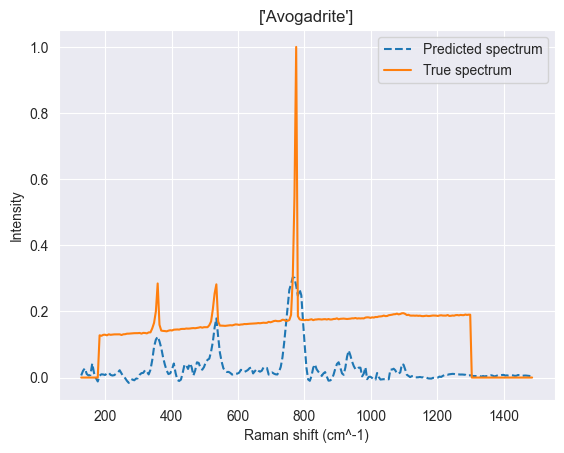

In [10]:
from pathlib import Path
dataset_path = '../data/processed/v6.pt'
dataset5 = Crystals(dataset_path,514)
train_dataset5, val_dataset5, test_dataset5 = dataset5.get_splits(deterministic=True)
model = painn_2
loss_name = "1mse_1cossim"
model_name = repr(model)
predict_dir_val = Path(f"predict/{model_name}_{loss_name}/val")
predict_dir_val.mkdir(parents=True,exist_ok=True)
predict_dir_test = Path(f"predict/{model_name}_{loss_name}/test")
predict_dir_test.mkdir(parents=True,exist_ok=True)
predict_dirs_test = {}
predict_dirs_val = {}
for i in dataset5.wl_list:
    path = Path(str(i))
    predict_dirs_val[i] = predict_dir_val/path
    predict_dirs_test[i] = predict_dir_test/path
    predict_dirs_val[i].mkdir(parents=True,exist_ok=True)
    predict_dirs_test[i].mkdir(parents=True,exist_ok=True)
save_all(model,"cpu",val_dataset5,predict_dir_val/"514",verbose=False)

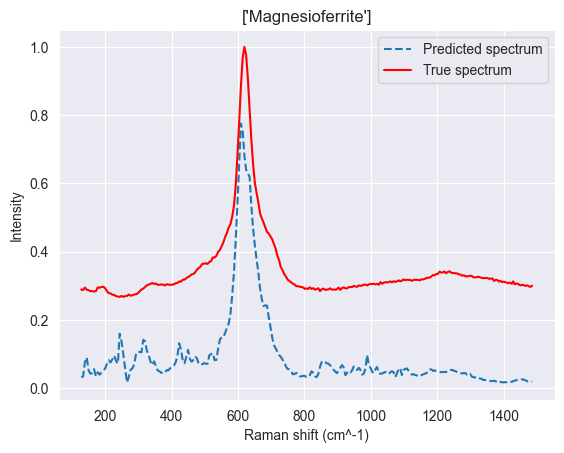

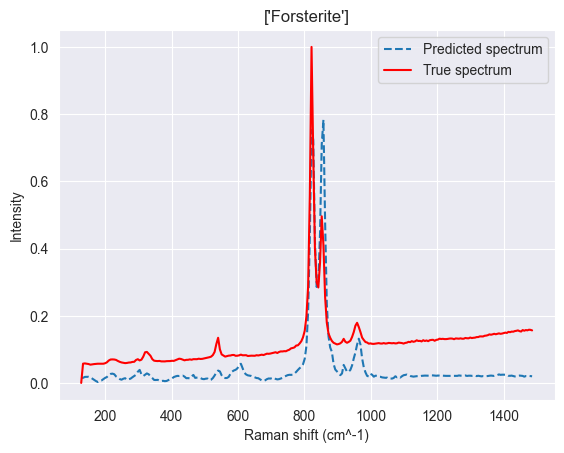

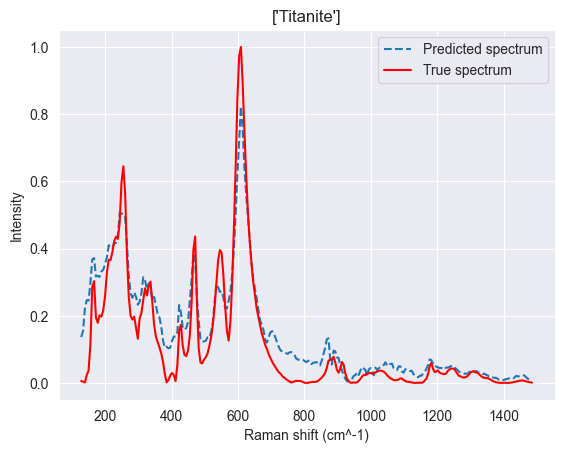

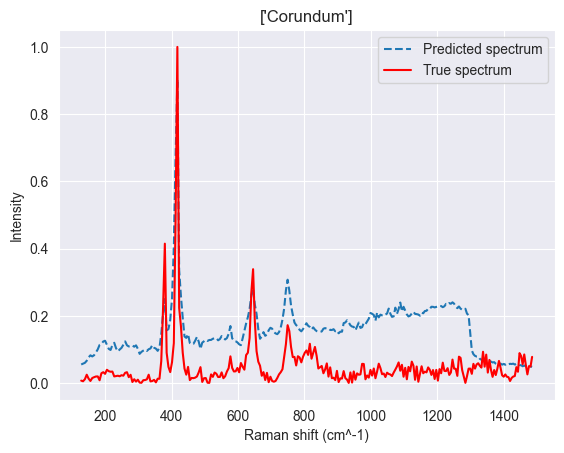

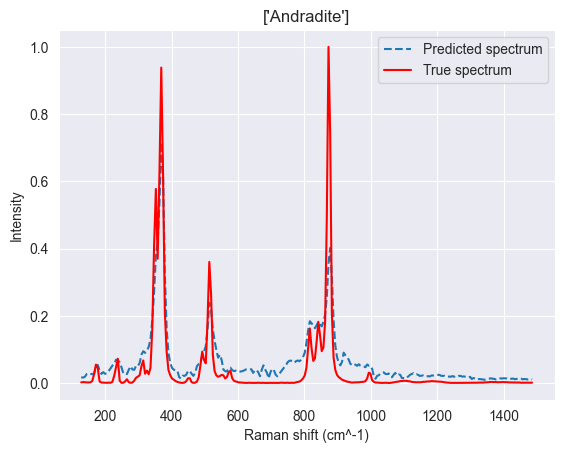

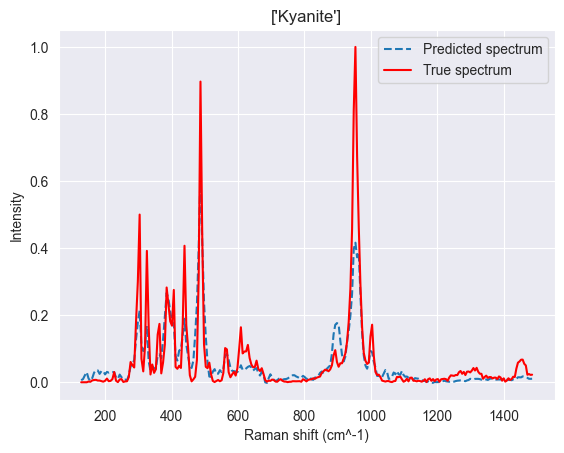

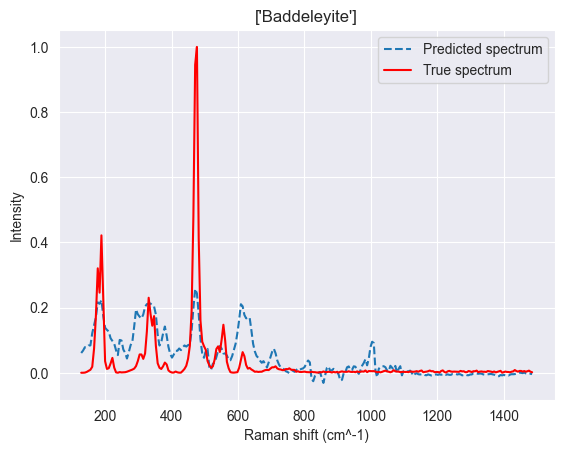

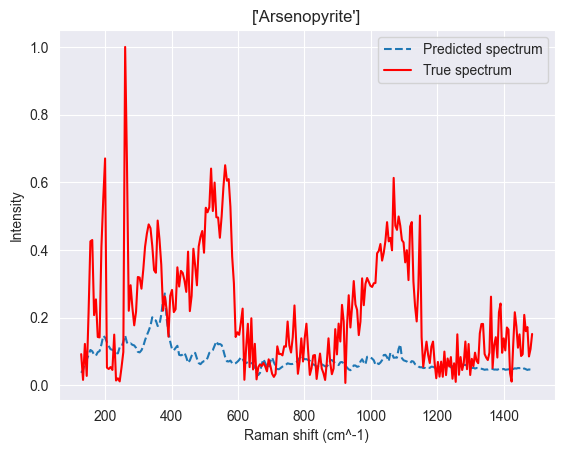

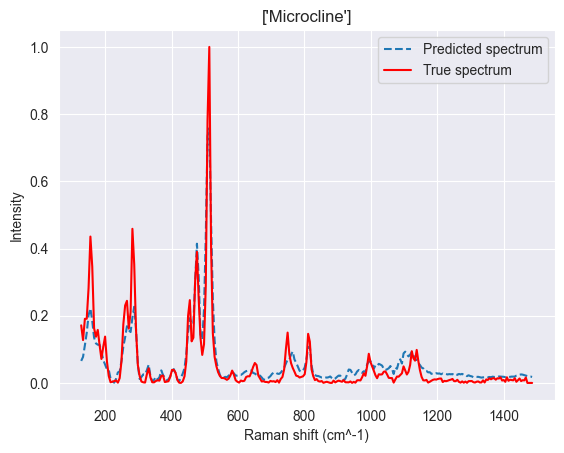

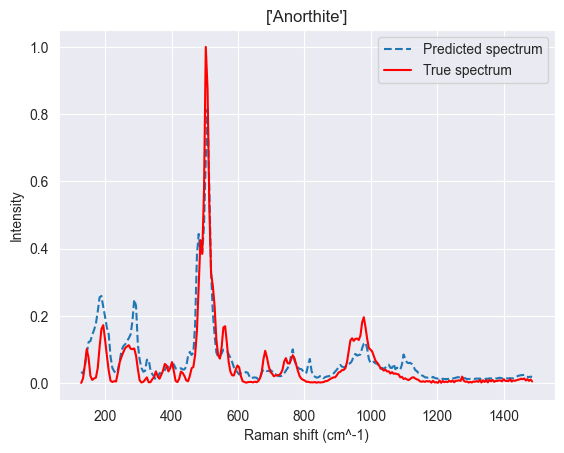

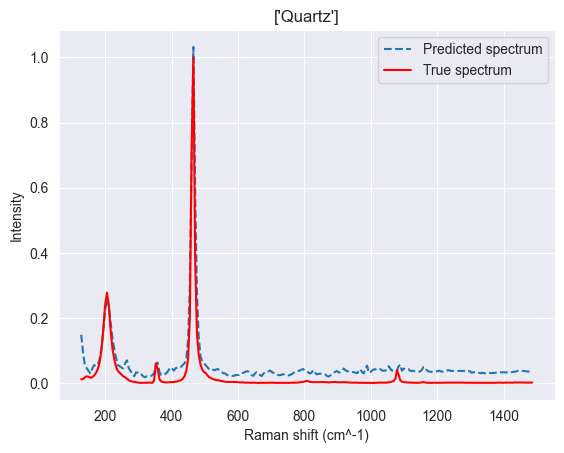

KeyboardInterrupt: 

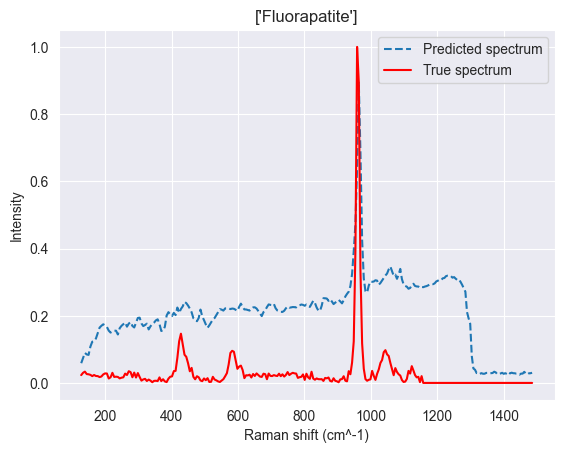

In [4]:
%reload_ext autoreload
%autoreload 2
from models import PaiNN_raman2, PaiNN_raman0, Ensemble1
from src.visualization.plotting import save_all
from src.data.dataset import Crystals
import torch
from pathlib import Path
painn_2 = PaiNN_raman2()
painn = PaiNN_raman0()
painn_path = "models/painn_1mse_1mae_1msle_1rmse_1cossim_1kl_/20251003-175924_epoch00734_1mse_1mae_1msle_1rmse_1cossim_1kl_0.4947.pt"
painn2_path = "models/painn2_1mse_1cossim/20251013-184836_epoch00809_kl0.0083.pt"
painn_2.load_state_dict(torch.load(painn2_path))
painn.load_state_dict(torch.load(painn_path))
ensemble = Ensemble1(painn_path, painn2_path)
model = ensemble
model_name = repr(model)
dataset_path = '../data/processed/v6.pt'
dataset5 = Crystals(dataset_path,514)
train_dataset5, val_dataset5, test_dataset5 = dataset5.get_splits(deterministic=True)
predict_dir_val = Path(f"predict/{model_name}/val")
predict_dir_val.mkdir(parents=True,exist_ok=True)
predict_dir_test = Path(f"predict/{model_name}/test")
predict_dir_test.mkdir(parents=True,exist_ok=True)
predict_dirs_test = {}
predict_dirs_val = {}
for i in dataset5.wl_list:
    path = Path(str(i))
    predict_dirs_val[i] = predict_dir_val/path
    predict_dirs_test[i] = predict_dir_test/path
    predict_dirs_val[i].mkdir(parents=True,exist_ok=True)
    predict_dirs_test[i].mkdir(parents=True,exist_ok=True)
save_all(model,"cpu",val_dataset5,predict_dir_val/"5144",verbose=True)